In [9]:
import torch
import torchvision

trainset = torchvision.datasets.MNIST(
    root='./data',
    train=True,
    download=True)

mean = trainset.data.float().mean() / 255
std = trainset.data.float().std() / 255

transform = torchvision.transforms.Compose(
    [torchvision.transforms.ToTensor(),
     torchvision.transforms.Normalize(mean, std)])

trainset.transform = transform

trainloader = torch.utils.data.DataLoader(
    trainset,
    batch_size=2048,
    shuffle=True)

testset = torchvision.datasets.MNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform)

testloader = torch.utils.data.DataLoader(testset, batch_size=1, shuffle=False)

In [10]:
class LeNet5(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.leNet = torch.nn.Sequential(

            torch.nn.Conv2d(in_channels=1,
                            out_channels=6,
                            kernel_size=5,
                            padding=2),
            torch.nn.Sigmoid(),
            torch.nn.AvgPool2d(kernel_size=2, stride=2),

            torch.nn.Conv2d(in_channels=6, out_channels=16, kernel_size=5),
            torch.nn.Sigmoid(),
            torch.nn.AvgPool2d(kernel_size=2, stride=2),

            torch.nn.Flatten(),

            torch.nn.Linear(5 * 5 * 16, 120),
            torch.nn.Sigmoid(),
            torch.nn.Linear(120, 84),
            torch.nn.Sigmoid(),
            torch.nn.Linear(84, 10)
        )
        self.dropout = torch.nn.Dropout(0.05)

    def forward(self, x):
        x = self.leNet(x)
        x = self.dropout(x)
        return x

In [11]:
if torch.cuda.is_available():
  device = "cuda"
else:
  device = "cpu"

print(f"Working on {device}")

net = LeNet5().to(device)
optimizer = torch.optim.Adam(net.parameters(), .001)

net.train()
for epoch in range(16):

  for batch, data in enumerate(trainloader):
    batch_inputs, batch_labels = data

    batch_inputs = batch_inputs.to(device)
    batch_labels = batch_labels.to(device)

    optimizer.zero_grad()

    batch_outputs = net(batch_inputs) # call to forward(self, x)

    loss = torch.nn.functional.cross_entropy(
        batch_outputs,
        batch_labels,
        reduction="mean")
    #print(f"epoch: {epoch}, batch: {batch}, current batch loss: {loss.item()}")

    loss.backward()
    optimizer.step() # update of the neural network

Working on cpu


In [12]:
correct = 0
net.eval()

with torch.no_grad(): # it prevents net from learning during evaluation
                      # we are not computating gradients, so this makes testing
                      # faster too
  for batch, data in enumerate(testloader):
    datapoint, label = data

    datapoint = datapoint.to(device)
    prediction = net(datapoint)
    classification = torch.argmax(prediction)
    correct += (classification.item() == label.item())

print(f"accuracy = {correct/testset.data.shape[0]}")


accuracy = 0.9412


#Task 1 - CNN Dreams: Last Homework Assignment Revisited

In [13]:
n_iter = 100
noise = torch.randn(10, 1, 28, 28)
targets = torch.arange(10)
noise = noise.to(device)
noise.requires_grad_(True)
targets = targets.to(device)
optimizer = torch.optim.Adam((noise,), lr=.05)

for _ in range(n_iter):
  optimizer.zero_grad()
  outputs = net(noise)

  ce_loss = torch.nn.functional.cross_entropy(outputs, targets)
  ce_loss.backward()
  optimizer.step()

with torch.no_grad():
  outputs = net(noise)
  probs = torch.softmax(outputs, dim=1)

  predicted = probs.argmax(dim=1)
  target_probs = probs[torch.arange(10), targets]

for i in range(10):
  print(
      f"target={targets[i].item()} | "
      f"pred={predicted[i].item()} | "
      f"p(target)={target_probs[i].item():.4f}"
      )

result = noise.detach().cpu()
print(ce_loss.item())



target=0 | pred=0 | p(target)=0.9908
target=1 | pred=1 | p(target)=0.9939
target=2 | pred=2 | p(target)=0.9925
target=3 | pred=3 | p(target)=0.9898
target=4 | pred=4 | p(target)=0.9829
target=5 | pred=5 | p(target)=0.9913
target=6 | pred=6 | p(target)=0.9892
target=7 | pred=7 | p(target)=0.9793
target=8 | pred=8 | p(target)=0.9914
target=9 | pred=9 | p(target)=0.9847
0.011517228558659554


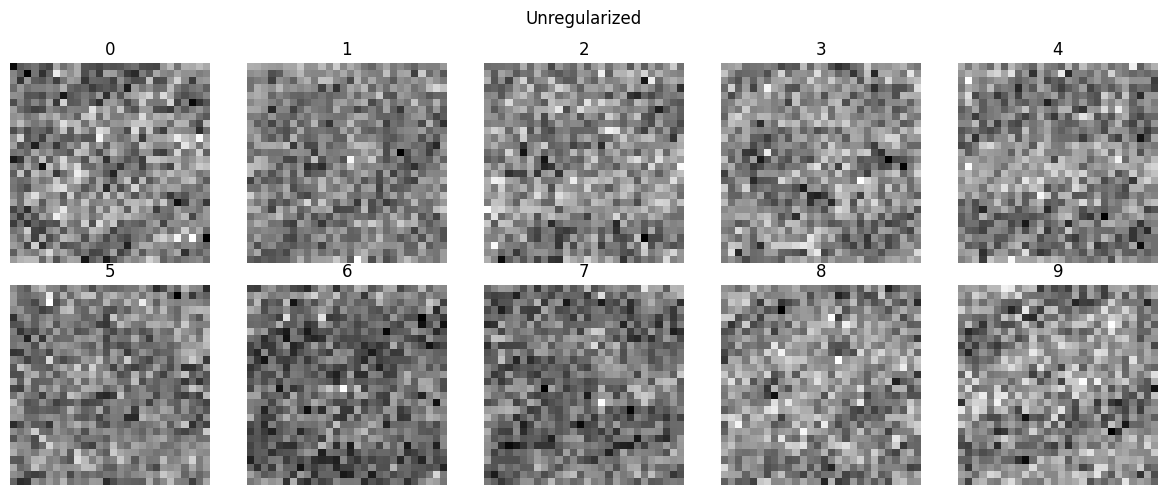

In [14]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
fig.suptitle(f"Unregularized")

for i, ax in enumerate(axes.flatten()):
  ax.imshow(result[i].squeeze(), cmap="gray")
  ax.set_title(f"{i}")
  ax.axis("off")

plt.tight_layout()
plt.show()

In [43]:
lambdas = (.01, 0.1, 1.0, 10.0)
results = {}
n_iter = 100

for l2_lambda in lambdas:

  noise = torch.randn(10, 1, 28, 28)
  targets = torch.arange(10)

  noise = noise.to(device)
  noise.requires_grad_(True)
  targets = targets.to(device)
  optimizer = torch.optim.Adam((noise,), lr=.05)

  for _ in range(n_iter):

    optimizer.zero_grad()
    outputs = net(noise)

    ce_loss = torch.nn.functional.cross_entropy(outputs, targets)
    l2_loss = l2_lambda * noise.pow(2).mean()
    total_loss = ce_loss + l2_loss

    total_loss.backward()
    optimizer.step()

  with torch.no_grad():
    outputs = net(noise)

    probs = torch.softmax(outputs, dim=1)

    predicted = probs.argmax(dim=1)

    target_probs = probs[torch.arange(10), targets]

  print(f"\nl2 lambda = {l2_lambda}")

  for i in range(10):
    print(
        f"target={targets[i].item()} | "
        f"pred={predicted[i].item()} | "
        f"p(target)={target_probs[i].item():.4f}"
        )

  results[l2_lambda] = noise.detach().cpu()
  print(f"final loss={total_loss.item():.6f}")




l2 lambda = 0.01
target=0 | pred=0 | p(target)=0.9906
target=1 | pred=1 | p(target)=0.9913
target=2 | pred=2 | p(target)=0.9920
target=3 | pred=3 | p(target)=0.9907
target=4 | pred=4 | p(target)=0.9856
target=5 | pred=5 | p(target)=0.9898
target=6 | pred=6 | p(target)=0.9887
target=7 | pred=7 | p(target)=0.9868
target=8 | pred=8 | p(target)=0.9917
target=9 | pred=9 | p(target)=0.9852
final loss=0.021933

l2 lambda = 0.1
target=0 | pred=0 | p(target)=0.9905
target=1 | pred=1 | p(target)=0.9926
target=2 | pred=2 | p(target)=0.9912
target=3 | pred=3 | p(target)=0.9894
target=4 | pred=4 | p(target)=0.9857
target=5 | pred=5 | p(target)=0.9910
target=6 | pred=6 | p(target)=0.9892
target=7 | pred=7 | p(target)=0.9860
target=8 | pred=8 | p(target)=0.9905
target=9 | pred=9 | p(target)=0.9836
final loss=0.085327

l2 lambda = 1.0
target=0 | pred=0 | p(target)=0.9884
target=1 | pred=1 | p(target)=0.9899
target=2 | pred=2 | p(target)=0.9918
target=3 | pred=3 | p(target)=0.9880
target=4 | pred=4 | 

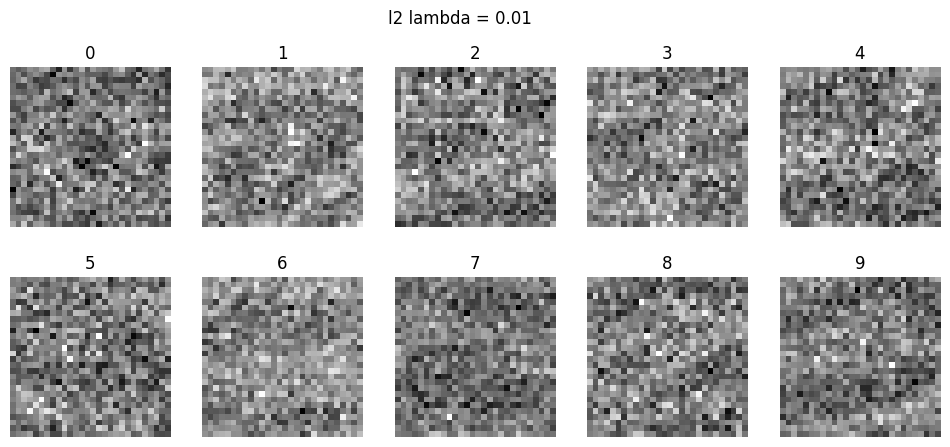

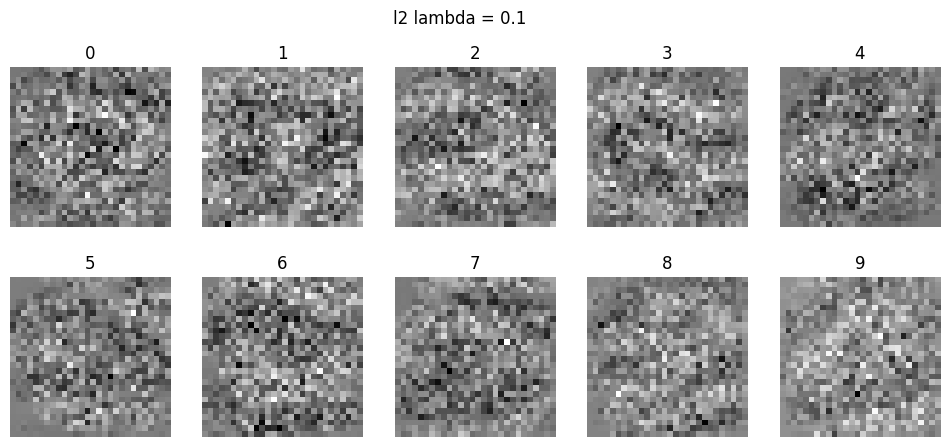

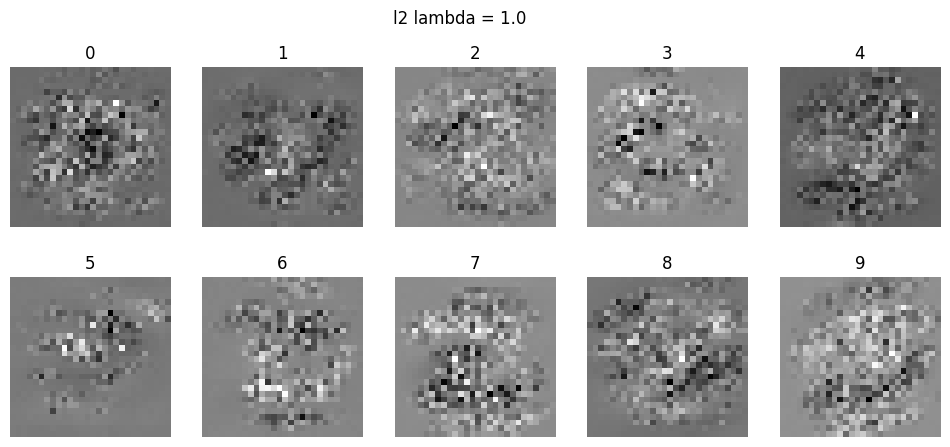

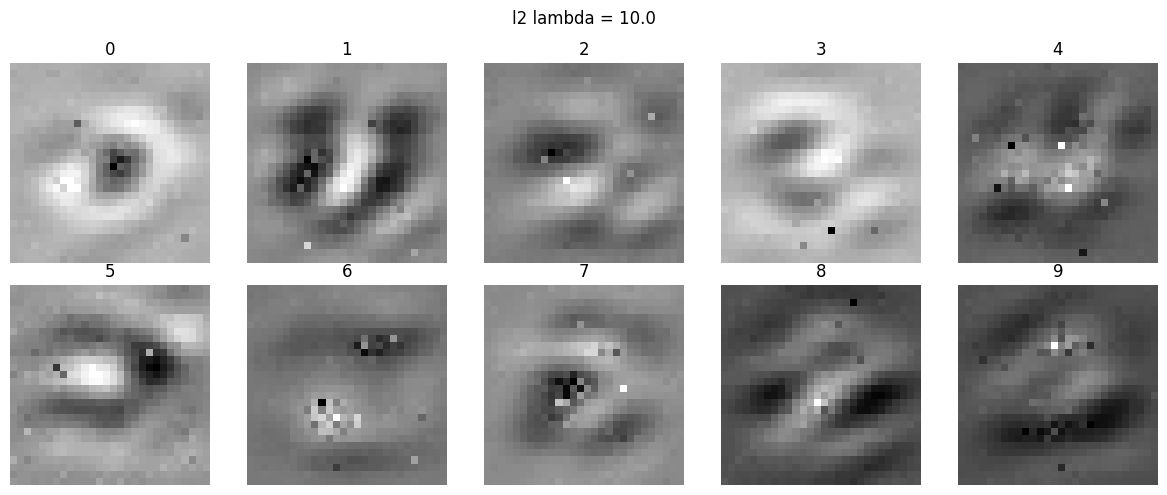

In [44]:
for l2_lambda, imgs in results.items():
  fig, axes = plt.subplots(2, 5, figsize=(12, 5))
  fig.suptitle(f"l2 lambda = {l2_lambda}")

  for i, ax in enumerate(axes.flatten()):
    ax.imshow(imgs[i].squeeze(), cmap='gray')
    ax.set_title(f"{i}")
    ax.axis("off")

plt.tight_layout()
plt.show()

## Comparison with MLP

Images generated by LeNet-5 with $\lambda_{l2}=10.0$ are more readable than those generated by an MLP. This is because, in LeNet-5, each feature map is computed using local convolutions, where each neuron depends only on nearby pixels. Local connectivity, weight sharing, and average pooling enforce spatial coherence and smooth low-frequency features, biasing the network toward learning structured digit-like patterns.

In contrast, an MLP lacks such spatial priors, allowing fragmented and high-frequency pixel interactions, which leads to less interpretable generated images.


# Task 2 - Adversarial Examokes: Fooling LeNet-5

In [45]:
from torch.utils.data import Subset

class_ctr = {}
selected_indices = []

for idx, label in enumerate(testset.targets):
    label = label.item()

    if class_ctr.setdefault(label, 0) < 10:
        selected_indices.append(idx)
        class_ctr[label] += 1

    if len(selected_indices) == 100:
        break

print(f"We selected {len(selected_indices)} images.")
subset = Subset(testset, selected_indices)
subsetloader = torch.utils.data.DataLoader(subset, batch_size=1)

We selected 100 images.


## Fast gradient sign method

This involves changing each pixel value in an image $\mathrm x$ by a fixed amount $\varepsilon$ with a sign determined by the gradient of an error function $E(\mathrm x, label)$, wich could for example be the negative log-likelihood.

We would get a modified image defined by
\begin{equation}
  \tilde{\mathrm x} = \mathrm x + \varepsilon \mathrm{sign}(\nabla_{\mathrm x} E(\mathrm x, label)).
\end{equation}

The $\varepsilon$ is keps small so as the changes would be undetectable to the human eye. We hope to get images that are misclassified by the network with high confidence.

In [59]:
epsilon = 0.1
successful_attacks = []

for batch, data in enumerate(subsetloader):
  datapoint, label = data

  datapoint = datapoint.to(device)
  label = label.to(device)

  datapoint.requires_grad_(True)

  output = net(datapoint)
  init_pred = torch.argmax(output, dim=1)

  if init_pred.item() != label.item():
    continue

  net.zero_grad()
  loss = torch.nn.functional.cross_entropy(output, label)
  loss.backward()

  data_grad = datapoint.grad.data
  sign_data_grad = data_grad.sign()

  probs = torch.nn.functional.softmax(output, dim=1)
  original_confidence = probs[0][init_pred.item()]

  min_val = (0.0 - mean) / std
  max_val = (1.0 - mean) / std

  noise = epsilon * sign_data_grad
  noise = torch.clamp(noise, min_val, max_val)

  prediction = net(noise)
  noise_classification = torch.argmax(prediction, dim=1)

  probs = torch.nn.functional.softmax(prediction, dim=1)
  noise_confidence = probs[0][noise_classification.item()]

  perturbed_image = datapoint + epsilon * sign_data_grad
  perturbed_image = torch.clamp(perturbed_image, min_val, max_val)

  prediction = net(perturbed_image)
  classification = torch.argmax(prediction, dim=1)

  probs = torch.nn.functional.softmax(prediction, dim=1)
  new_confidence = probs[0][classification.item()]

  if (
      classification.item() != label.item() and
      new_confidence.item() > 0.5 and
      original_confidence.item() > 0.5
      ):

      successful_attacks.append(
          {
              "original_image": datapoint.detach().cpu(),
              "perturbed_image": perturbed_image.detach().cpu(),
              "noise": sign_data_grad.detach().cpu(),
              "original_label": label.item(),
              "noise_label": noise_classification.item(),
              "new_label": classification.item(),
              "original_confidence": original_confidence.item(),
              "noise_confidence": noise_confidence.item(),
              "new_confidence": new_confidence.item()
          })

print(f"We fooled Le-Net5 {len(successful_attacks)} times.")

We fooled Le-Net5 3 times.


Example of an adversarial attack against a trained convolutional network:

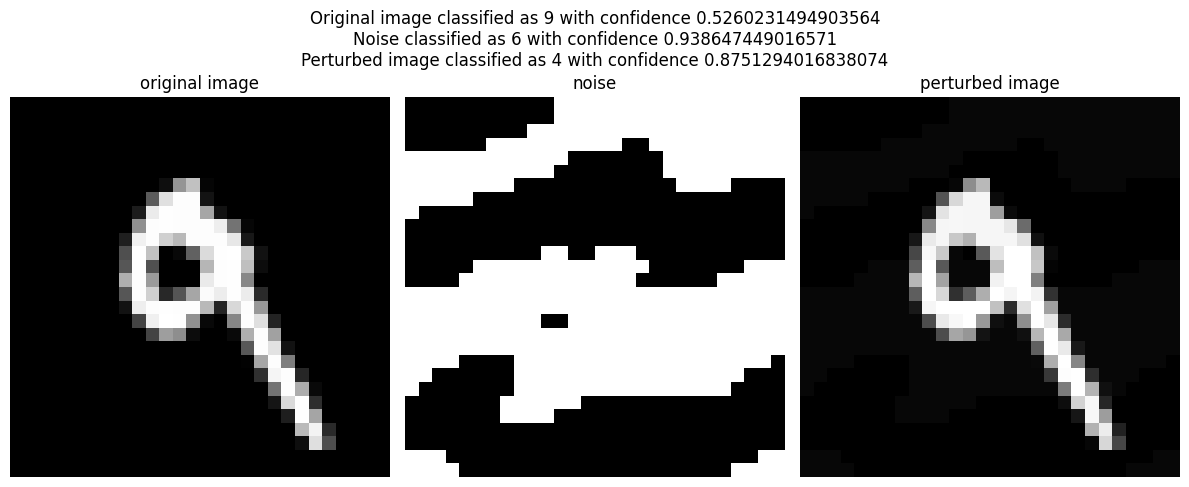

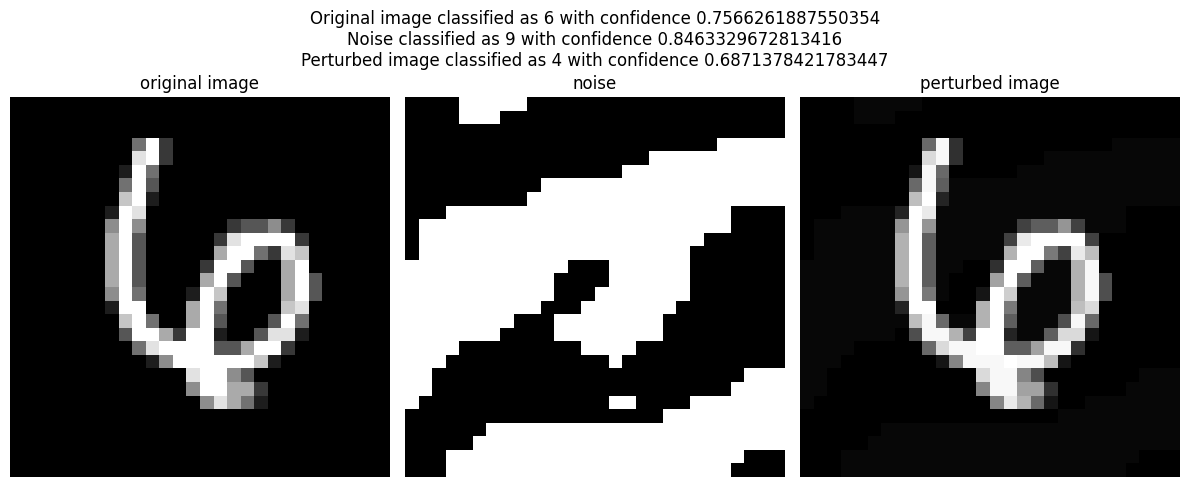

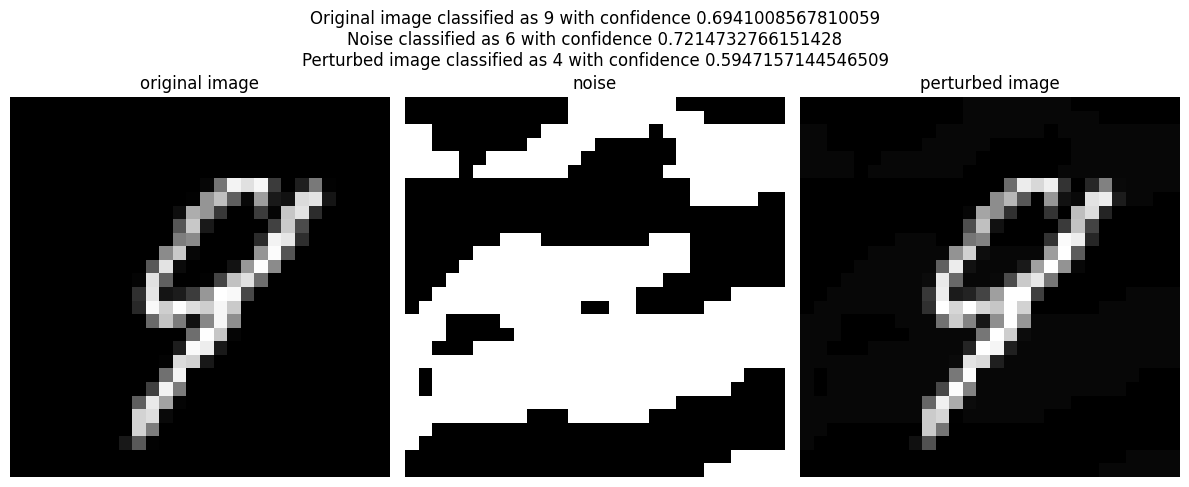

In [60]:
for attack_data in successful_attacks[:5]:

  fig, axes = plt.subplots(1, 3, figsize=(12, 5))
  fig.suptitle(
      f"Original image classified as {attack_data['original_label']} "
      f"with confidence {attack_data['original_confidence']}\n"
      f"Noise classified as {attack_data['noise_label']} "
      f"with confidence {attack_data['noise_confidence']}\n"
      f"Perturbed image classified as {attack_data['new_label']} "
      f"with confidence {attack_data['new_confidence']}"
  )

  axes[0].imshow(attack_data["original_image"].squeeze(), cmap='gray')
  axes[0].set_title("original image")
  axes[0].axis("off")

  axes[1].imshow(attack_data["noise"].squeeze(), cmap='gray')
  axes[1].set_title("noise")
  axes[1].axis("off")

  axes[2].imshow(attack_data["perturbed_image"].squeeze(), cmap='gray')
  axes[2].set_title("perturbed image")
  axes[2].axis("off")

  plt.tight_layout()
  plt.show()